# ACDC Dataset Analysis

Exploratory checks for the preprocessed ACDC HDF5 dataset. The notebook summarizes file layout, HDF5 keys, image/label shapes, patient and frame coverage, label balance, and visual samples.

**What this cell does:** This cell imports the analysis libraries, configures notebook display settings, and locates the `ACDC_preprocessed` dataset folder relative to the project root.

In [11]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT = PROJECT_ROOT / "ACDC_preprocessed"
assert DATA_ROOT.exists(), f"Dataset folder not found: {DATA_ROOT}"

DATA_ROOT

PosixPath('/home/basic/Faks/Automated-Cardiac-Diagnosis-Challenge/ACDC_preprocessed')

## File Layout

**What this cell does:** This cell discovers all HDF5 files in the dataset and summarizes how many files and megabytes are present in each dataset subfolder.

In [12]:
h5_files = sorted(DATA_ROOT.glob("**/*.h5"))
print(f"Total HDF5 files: {len(h5_files):,}")

layout = []
for folder in sorted(p for p in DATA_ROOT.iterdir() if p.is_dir()):
    files = sorted(folder.glob("*.h5"))
    layout.append({
        "split": folder.name,
        "files": len(files),
        "size_mb": sum(f.stat().st_size for f in files) / 1024**2,
    })

layout_df = pd.DataFrame(layout)
layout_df

Total HDF5 files: 2,212


,split,files,size_mb
0,ACDC_testing_volumes,100,53.297203
1,ACDC_training_slices,1912,139.172810
2,ACDC_training_volumes,200,117.114828


**What this cell does:** This cell parses patient, frame, and slice numbers from each filename, handles copied-file suffixes like `(1)`, and builds the dataset manifest table.

In [13]:
def remove_copy_suffix(name: str) -> str:
    stem = Path(name).stem
    suffix = Path(name).suffix
    if stem.endswith(")") and "(" in stem:
        base, copy_number = stem.rsplit("(", 1)
        if copy_number[:-1].isdigit():
            stem = base
    return f"{stem}{suffix}"


def parse_file(path: Path) -> dict:
    clean_name = remove_copy_suffix(path.name)
    parts = Path(clean_name).stem.split("_")
    info = {
        "path": path,
        "split": path.parent.name,
        "file": path.name,
        "size_kb": path.stat().st_size / 1024,
    }
    if len(parts) >= 2:
        info["patient"] = int(parts[0].removeprefix("patient"))
        info["frame"] = int(parts[1].removeprefix("frame"))
        info["slice"] = int(parts[3]) if len(parts) == 4 and parts[2] == "slice" else None
    return info

manifest = pd.DataFrame(parse_file(path) for path in h5_files)
manifest["kind"] = np.where(manifest["slice"].isna(), "volume", "slice")
manifest.head()

,path,split,file,size_kb,patient,frame,slice,kind
0,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,ACDC_testing_volumes,patient101_frame01.h5,637.666016,101,1,NaN,volume
1,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,ACDC_testing_volumes,patient101_frame14.h5,593.673828,101,14,NaN,volume
2,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,ACDC_testing_volumes,patient102_frame01.h5,463.086914,102,1,NaN,volume
3,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,ACDC_testing_volumes,patient102_frame13.h5,458.013672,102,13,NaN,volume
4,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,ACDC_testing_volumes,patient103_frame01.h5,518.853516,103,1,NaN,volume


**What this cell does:** This cell summarizes coverage by split: file counts, number of patients, number of frames, patient ID range, and total storage size.

In [14]:
coverage = (
    manifest.groupby(["split", "kind"])
    .agg(
        files=("file", "count"),
        patients=("patient", "nunique"),
        frames=("frame", "nunique"),
        min_patient=("patient", "min"),
        max_patient=("patient", "max"),
        size_mb=("size_kb", lambda x: x.sum() / 1024),
    )
    .reset_index()
)
coverage

,split,kind,files,patients,frames,min_patient,max_patient,size_mb
0,ACDC_testing_volumes,volume,100,50,11,101,150,53.297203
1,ACDC_training_slices,slice,1912,100,13,1,100,139.172810
2,ACDC_training_volumes,volume,200,100,13,1,100,117.114828


**What this cell does:** This cell checks for duplicate-looking files by comparing names after removing copied-file suffixes such as `(1)`.

In [15]:
normalized_name = manifest["file"].map(remove_copy_suffix)
duplicates = manifest.assign(normalized_name=normalized_name)
duplicates = duplicates[duplicates.duplicated(["split", "normalized_name"], keep=False)]
print(f"Duplicate-looking files after removing '(n)' suffixes: {len(duplicates):,}")
duplicates.sort_values(["split", "normalized_name", "file"]).head(20)

Duplicate-looking files after removing '(n)' suffixes: 20


,path,split,file,size_kb,patient,frame,slice,kind,normalized_name
102,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,ACDC_training_slices,patient001_frame01_slice_2(1).h5,84.223633,1,1,2.0,slice,patient001_frame01_slice_2.h5
103,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,ACDC_training_slices,patient001_frame01_slice_2.h5,84.223633,1,1,2.0,slice,patient001_frame01_slice_2.h5
104,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,ACDC_training_slices,patient001_frame01_slice_3(1).h5,84.129883,1,1,3.0,slice,patient001_frame01_slice_3.h5
105,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,ACDC_training_slices,patient001_frame01_slice_3.h5,84.129883,1,1,3.0,slice,patient001_frame01_slice_3.h5
106,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,ACDC_training_slices,patient001_frame01_slice_4(1).h5,83.675781,1,1,4.0,slice,patient001_frame01_slice_4.h5
107,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,ACDC_training_slices,patient001_frame01_slice_4.h5,83.675781,1,1,4.0,slice,patient001_frame01_slice_4.h5
108,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,ACDC_training_slices,patient001_frame01_slice_5(1).h5,82.697266,1,1,5.0,slice,patient001_frame01_slice_5.h5
109,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,ACDC_training_slices,patient001_frame01_slice_5.h5,82.697266,1,1,5.0,slice,patient001_frame01_slice_5.h5
110,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,ACDC_training_slices,patient001_frame01_slice_6(1).h5,80.534180,1,1,6.0,slice,patient001_frame01_slice_6.h5
111,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,ACDC_training_slices,patient001_frame01_slice_6.h5,80.534180,1,1,6.0,slice,patient001_frame01_slice_6.h5


## HDF5 Schema And Shapes

**What this cell does:** This cell inspects representative HDF5 files from each split and reports the dataset keys, array shapes, and data types stored inside them.

In [16]:
def inspect_h5(path: Path) -> list[dict]:
    rows = []
    with h5py.File(path, "r") as h5:
        for key in sorted(h5.keys()):
            ds = h5[key]
            rows.append({
                "file": path.name,
                "split": path.parent.name,
                "key": key,
                "shape": tuple(ds.shape),
                "dtype": str(ds.dtype),
            })
    return rows

schema_rows = []
for split, group in manifest.groupby("split"):
    for path in group["path"].head(3):
        schema_rows.extend(inspect_h5(path))

schema_df = pd.DataFrame(schema_rows)
schema_df

,file,split,key,shape,dtype
0,patient101_frame01.h5,ACDC_testing_volumes,image,"(10, 256, 232)",float32
1,patient101_frame01.h5,ACDC_testing_volumes,label,"(10, 256, 232)",uint8
2,patient101_frame14.h5,ACDC_testing_volumes,image,"(10, 256, 232)",float32
3,patient101_frame14.h5,ACDC_testing_volumes,label,"(10, 256, 232)",uint8
4,patient102_frame01.h5,ACDC_testing_volumes,image,"(8, 256, 216)",float32
5,patient102_frame01.h5,ACDC_testing_volumes,label,"(8, 256, 216)",uint8
6,patient001_frame01_slice_0.h5,ACDC_training_slices,image,"(256, 216)",float32
7,patient001_frame01_slice_0.h5,ACDC_training_slices,label,"(256, 216)",uint8
8,patient001_frame01_slice_0.h5,ACDC_training_slices,scribble,"(256, 216)",uint16
9,patient001_frame01_slice_1.h5,ACDC_training_slices,image,"(256, 216)",float32


**What this cell does:** This cell scans the selected HDF5 files and collects per-file image statistics, label values, foreground fractions, and scribble coverage.

In [17]:
def summarize_file(path: Path) -> dict:
    row = parse_file(path)
    with h5py.File(path, "r") as h5:
        image = h5["image"]
        row["image_shape"] = tuple(image.shape)
        row["image_dtype"] = str(image.dtype)
        row["image_min"] = float(np.min(image))
        row["image_max"] = float(np.max(image))
        row["image_mean"] = float(np.mean(image))
        row["image_std"] = float(np.std(image))
        row["keys"] = ",".join(sorted(h5.keys()))
        if "label" in h5:
            labels = h5["label"][:]
            values, counts = np.unique(labels, return_counts=True)
            row["label_values"] = tuple(int(v) for v in values)
            row["foreground_fraction"] = float((labels > 0).mean())
            for value, count in zip(values, counts):
                row[f"label_{int(value)}_pixels"] = int(count)
        if "scribble" in h5:
            scribble = h5["scribble"][:]
            row["scribble_fraction"] = float((scribble > 0).mean())
            row["scribble_values"] = tuple(int(v) for v in np.unique(scribble))
    return row

# Full scan is fine for the small test dataset. Set ANALYZE_ALL=False to sample faster.
ANALYZE_ALL = True
MAX_FILES_PER_SPLIT = 50

paths_to_scan = []
for split, group in manifest.groupby("split"):
    paths = list(group["path"])
    if not ANALYZE_ALL:
        paths = paths[:MAX_FILES_PER_SPLIT]
    paths_to_scan.extend(paths)

summary_df = pd.DataFrame(summarize_file(path) for path in tqdm(paths_to_scan, desc="Scanning HDF5 files"))
summary_df.head()

Scanning HDF5 files:   0%|          | 0/2212 [00:00<?, ?it/s]

,path,split,file,size_kb,patient,frame,slice,image_shape,image_dtype,image_min,image_max,image_mean,image_std,keys,label_values,foreground_fraction,label_0_pixels,label_1_pixels,label_2_pixels,label_3_pixels,scribble_fraction,scribble_values
0,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,ACDC_testing_volumes,patient101_frame01.h5,637.666016,101,1,NaN,"(10, 256, 232)",float32,0.0,1.0,0.247006,0.238398,"image,label","(0, 1, 2, 3)",0.030024,576088,4822.0,4740.0,8270.0,NaN,NaN
1,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,ACDC_testing_volumes,patient101_frame14.h5,593.673828,101,14,NaN,"(10, 256, 232)",float32,0.0,1.0,0.242148,0.233135,"image,label","(0, 1, 2, 3)",0.022198,580736,2603.0,4785.0,5796.0,NaN,NaN
2,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,ACDC_testing_volumes,patient102_frame01.h5,463.086914,102,1,NaN,"(8, 256, 216)",float32,0.0,1.0,0.330010,0.275291,"image,label","(0, 1, 2, 3)",0.023395,432019,4100.0,2995.0,3254.0,NaN,NaN
3,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,ACDC_testing_volumes,patient102_frame13.h5,458.013672,102,13,NaN,"(8, 256, 216)",float32,0.0,1.0,0.331584,0.273795,"image,label","(0, 1, 2, 3)",0.014572,435922,2040.0,3458.0,948.0,NaN,NaN
4,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,ACDC_testing_volumes,patient103_frame01.h5,518.853516,103,1,NaN,"(9, 256, 216)",float32,0.0,1.0,0.333056,0.260486,"image,label","(0, 1, 2, 3)",0.036282,479608,3641.0,7117.0,7298.0,NaN,NaN


**What this cell does:** This cell counts how often each image shape appears in each split, which helps reveal whether files have consistent spatial dimensions.

In [18]:
shape_summary = (
    summary_df.groupby(["split", "image_shape"])
    .size()
    .reset_index(name="files")
    .sort_values(["split", "files"], ascending=[True, False])
)
shape_summary.head(20)

,split,image_shape,files
10,ACDC_testing_volumes,"(9, 256, 216)",12
14,ACDC_testing_volumes,"(10, 216, 256)",10
5,ACDC_testing_volumes,"(8, 256, 216)",8
17,ACDC_testing_volumes,"(10, 256, 216)",6
19,ACDC_testing_volumes,"(10, 256, 232)",6
6,ACDC_testing_volumes,"(9, 216, 256)",4
22,ACDC_testing_volumes,"(11, 256, 216)",4
0,ACDC_testing_volumes,"(6, 256, 214)",2
1,ACDC_testing_volumes,"(8, 166, 240)",2
2,ACDC_testing_volumes,"(8, 180, 224)",2


## Intensity And Label Distributions

**What this cell does:** This cell displays descriptive statistics and plots distributions for image intensity and foreground-label fraction across dataset splits.

image_min                                            \
                          count    mean     std  min  25%     50%     75%   
split                                                                       
ACDC_testing_volumes      100.0  0.0000  0.0000  0.0  0.0  0.0000  0.0000   
ACDC_training_slices     1912.0  0.0101  0.0163  0.0  0.0  0.0044  0.0148   
ACDC_training_volumes     200.0  0.0000  0.0000  0.0  0.0  0.0000  0.0000   

                              image_max                                     \
                          max     count mean  std  min  25%  50%  75%  max   
split                                                                        
ACDC_testing_volumes   0.0000     100.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0   
ACDC_training_slices   0.1155    1912.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0   
ACDC_training_volumes  0.0000     200.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0   

                      image_mean                                          \
                           count    mean     std     min     25%     50%   
split                                                                      
ACDC_testing_volumes       100.0  0.2601  0.0487  0.1436  0.2288  0.2548   
ACDC_training_slices      1912.0  0.2354  0.0469  0.0951  0.2039  0.2355   
ACDC_training_volumes      200.0  0.2367  0.0446  0.1340  0.2067  0.2394   

                                      image_std                          \
                          75%     max     count    mean     std     min   
split                                                                     
ACDC_testing_volumes   0.2926  0.3683     100.0  0.2393  0.0221  0.1729   
ACDC_training_slices   0.2626  0.3864    1912.0  0.2327  0.0268  0.1469   
ACDC_training_volumes  0.2625  0.3664     200.0  0.2342  0.0245  0.1731   

                                                      foreground_fraction  \
                          25%     50%     75%     max               count   
split                                                                       
ACDC_testing_volumes   0.2254  0.2411  0.2533  0.2812               100.0   
ACDC_training_slices   0.2158  0.2321  0.2499  0.3086              1912.0   
ACDC_training_volumes  0.2179  0.2359  0.2497  0.2895               200.0   

                                                                               \
                         mean     std     min     25%     50%     75%     max   
split                                                                           
ACDC_testing_volumes   0.0376  0.0129  0.0146  0.0284  0.0357  0.0470  0.0773   
ACDC_training_slices   0.0381  0.0223  0.0000  0.0209  0.0366  0.0540  0.1138   
ACDC_training_volumes  0.0373  0.0122  0.0135  0.0285  0.0360  0.0451  0.0769   

                      scribble_fraction                                  \
                                  count    mean     std     min     25%   
split                                                                     
ACDC_testing_volumes                0.0     NaN     NaN     NaN     NaN   
ACDC_training_slices             1912.0  0.9935  0.0021  0.9733  0.9922   
ACDC_training_volumes             200.0  0.9936  0.0016  0.9893  0.9925   

                                               
                          50%     75%     max  
split                                          
ACDC_testing_volumes      NaN     NaN     NaN  
ACDC_training_slices   0.9936  0.9949  0.9985  
ACDC_training_volumes  0.9940  0.9947  0.9970

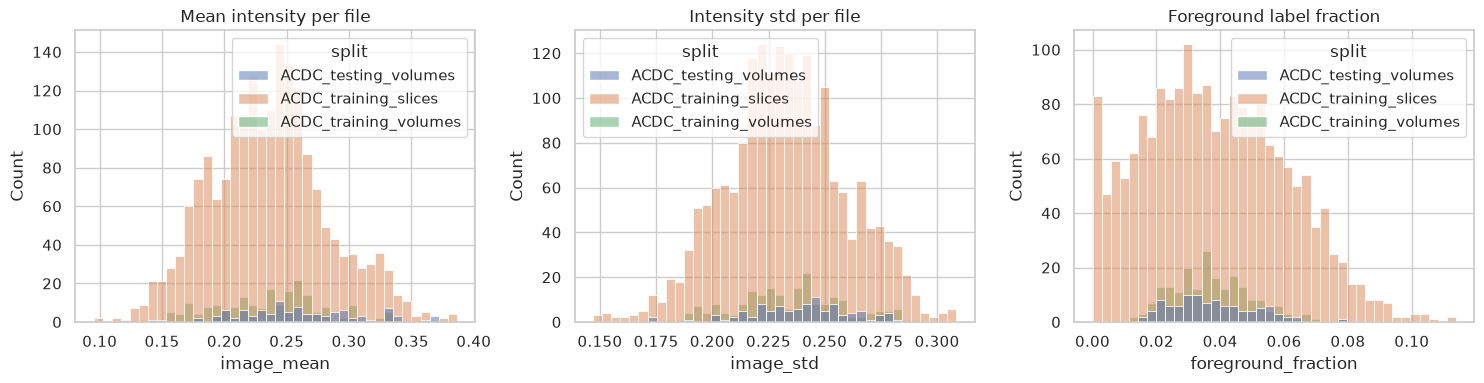

In [19]:
display(summary_df.groupby("split")[["image_min", "image_max", "image_mean", "image_std", "foreground_fraction", "scribble_fraction"]].describe().round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(summary_df, x="image_mean", hue="split", bins=40, ax=axes[0])
sns.histplot(summary_df, x="image_std", hue="split", bins=40, ax=axes[1])
sns.histplot(summary_df.dropna(subset=["foreground_fraction"]), x="foreground_fraction", hue="split", bins=40, ax=axes[2])
axes[0].set_title("Mean intensity per file")
axes[1].set_title("Intensity std per file")
axes[2].set_title("Foreground label fraction")
plt.tight_layout()

**What this cell does:** This cell totals the number of pixels in each segmentation label and plots the class balance by split.

,label_0_pixels,label_1_pixels,label_2_pixels,label_3_pixels
split,,,,
ACDC_testing_volumes,51503981,689128,646822,661957
ACDC_training_slices,98720333,1240319,1334992,1310244
ACDC_training_volumes,98189937,1236051,1328344,1298596


,label_0_pixels,label_1_pixels,label_2_pixels,label_3_pixels
split,,,,
ACDC_testing_volumes,0.96266,0.01288,0.01209,0.01237
ACDC_training_slices,0.96213,0.01209,0.01301,0.01277
ACDC_training_volumes,0.96215,0.01211,0.01302,0.01272


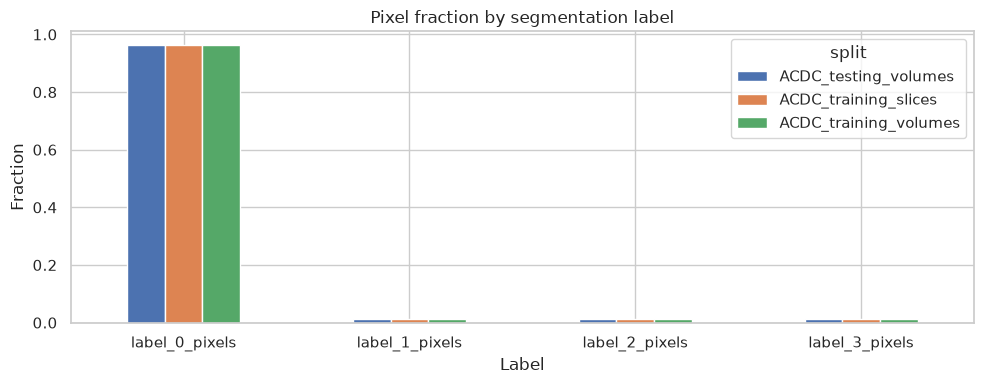

In [20]:
label_cols = [c for c in summary_df.columns if c.startswith("label_") and c.endswith("_pixels")]
label_cols = sorted(label_cols, key=lambda c: int(c.split("_")[1]))
label_totals = summary_df.groupby("split")[label_cols].sum(min_count=1).fillna(0).astype(int)
label_fractions = label_totals.div(label_totals.sum(axis=1), axis=0)

display(label_totals)
display(label_fractions.round(5))

label_fractions.T.plot(kind="bar", figsize=(10, 4))
plt.title("Pixel fraction by segmentation label")
plt.xlabel("Label")
plt.ylabel("Fraction")
plt.xticks(rotation=0)
plt.tight_layout()

## Patient, Frame, And Slice Coverage

**What this cell does:** This cell summarizes patient-level coverage and plots how many files and frames are available per patient.

,split,patient,files,frames,slices
0,ACDC_testing_volumes,101,2,2,0
1,ACDC_testing_volumes,102,2,2,0
2,ACDC_testing_volumes,103,2,2,0
3,ACDC_testing_volumes,104,2,2,0
4,ACDC_testing_volumes,105,2,2,0
5,ACDC_testing_volumes,106,2,2,0
6,ACDC_testing_volumes,107,2,2,0
7,ACDC_testing_volumes,108,2,2,0
8,ACDC_testing_volumes,109,2,2,0
9,ACDC_testing_volumes,110,2,2,0


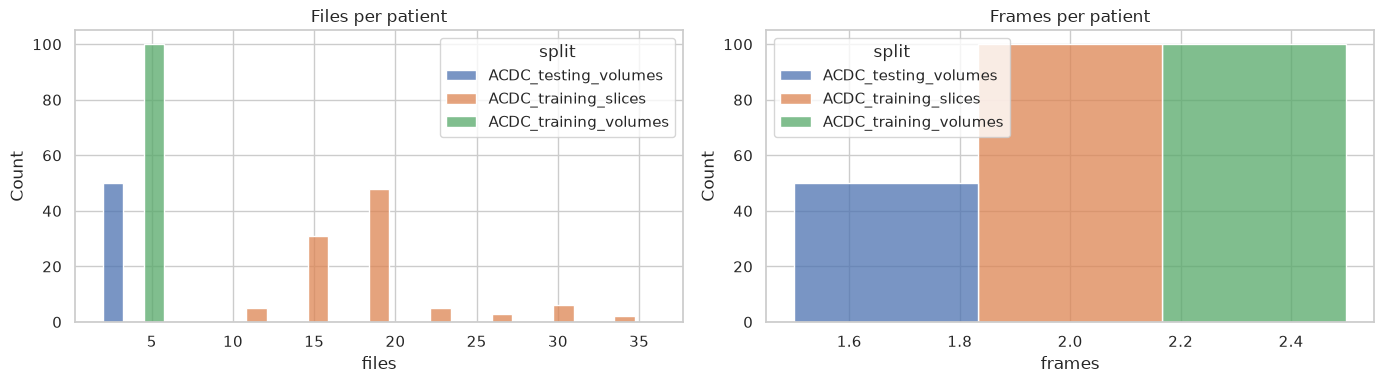

In [21]:
patient_frame_counts = (
    manifest.groupby(["split", "patient"])
    .agg(files=("file", "count"), frames=("frame", "nunique"), slices=("slice", "count"))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(patient_frame_counts, x="files", hue="split", multiple="dodge", ax=axes[0])
sns.histplot(patient_frame_counts, x="frames", hue="split", multiple="dodge", discrete=True, ax=axes[1])
axes[0].set_title("Files per patient")
axes[1].set_title("Frames per patient")
plt.tight_layout()

patient_frame_counts.head(20)

## Visual Samples

**What this cell does:** This cell loads a few high-foreground examples and visualizes the image, segmentation label, overlay, and scribble annotation when available.

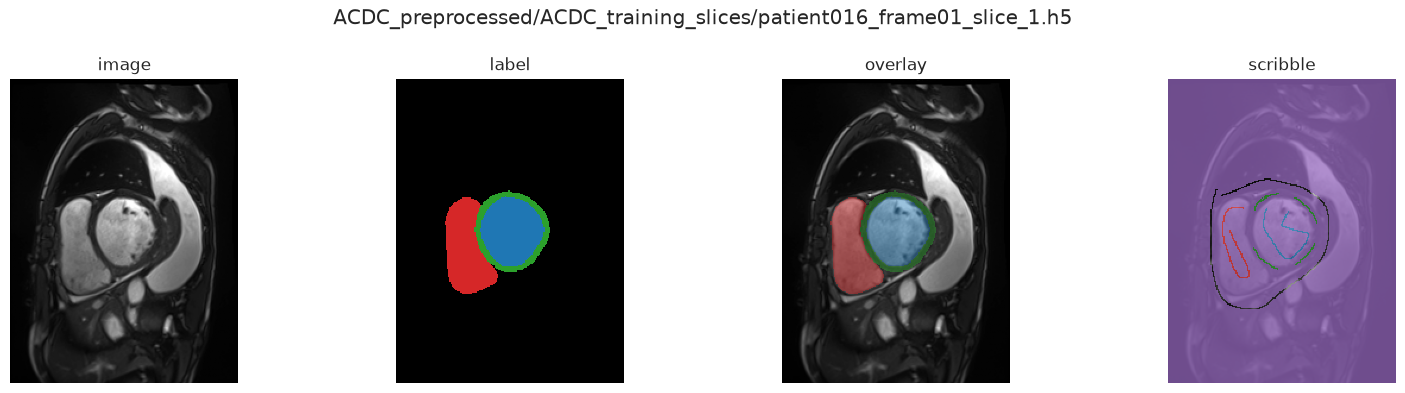

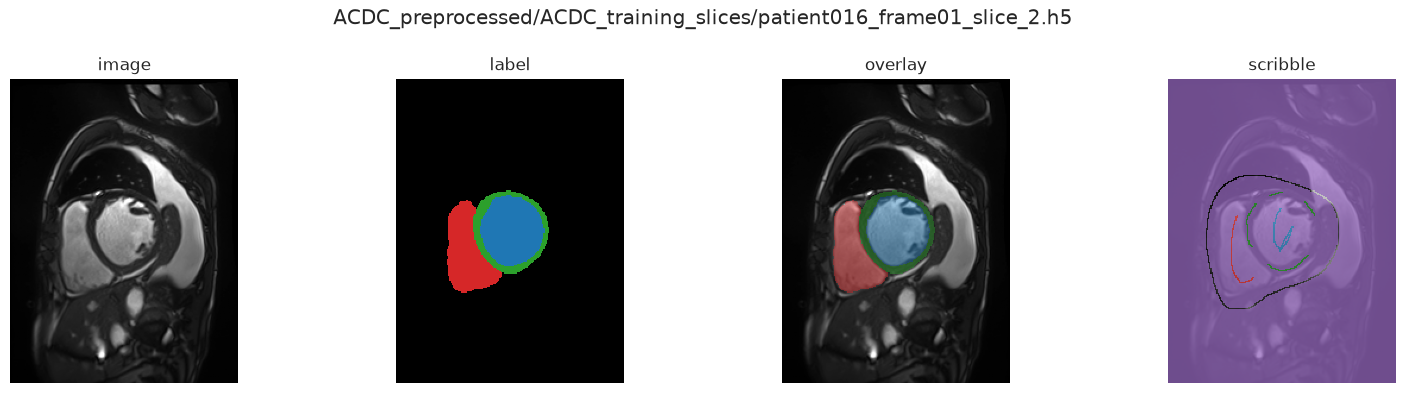

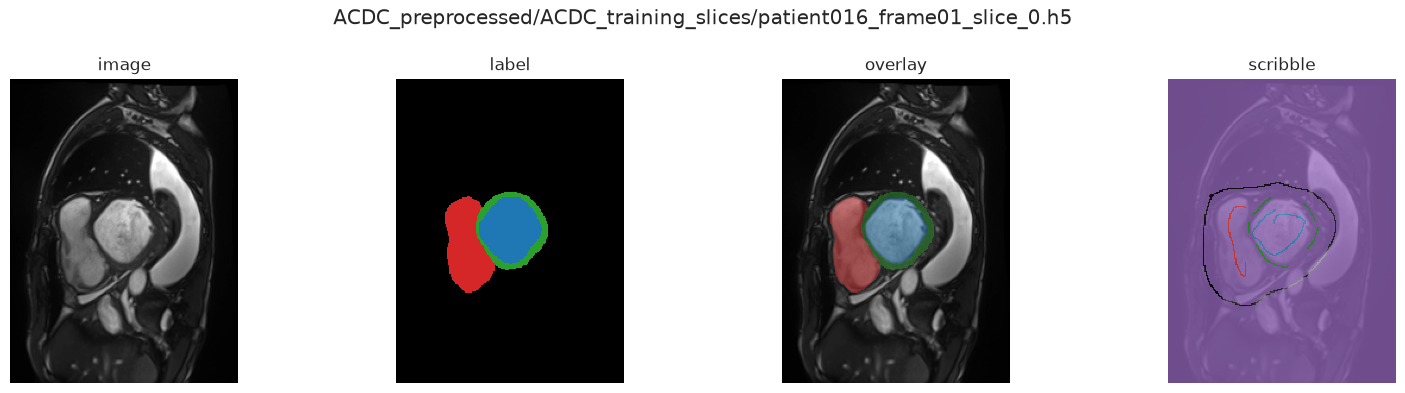

In [22]:
label_cmap = ListedColormap(["black", "tab:red", "tab:green", "tab:blue", "tab:purple"])

def read_sample(path: Path):
    with h5py.File(path, "r") as h5:
        data = {key: h5[key][:] for key in h5.keys()}
    return data

def select_2d(arr: np.ndarray) -> np.ndarray:
    if arr.ndim == 2:
        return arr
    if arr.ndim == 3:
        return arr[arr.shape[0] // 2]
    raise ValueError(f"Expected 2D or 3D array, got shape {arr.shape}")

def plot_case(path: Path):
    data = read_sample(path)
    image = select_2d(data["image"])
    label = select_2d(data["label"]) if "label" in data else None
    scribble = select_2d(data["scribble"]) if "scribble" in data else None

    ncols = 3 + int(scribble is not None)
    fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 4))
    axes = np.atleast_1d(axes)
    fig.suptitle(str(path.relative_to(PROJECT_ROOT)))

    axes[0].imshow(image, cmap="gray")
    axes[0].set_title("image")
    if label is not None:
        axes[1].imshow(label, cmap=label_cmap, interpolation="nearest", vmin=0, vmax=4)
        axes[1].set_title("label")
        axes[2].imshow(image, cmap="gray")
        axes[2].imshow(np.ma.masked_where(label == 0, label), cmap=label_cmap, alpha=0.45, interpolation="nearest", vmin=0, vmax=4)
        axes[2].set_title("overlay")
    if scribble is not None:
        axes[-1].imshow(image, cmap="gray")
        axes[-1].imshow(np.ma.masked_where(scribble == 0, scribble), cmap=label_cmap, alpha=0.75, interpolation="nearest", vmin=0, vmax=4)
        axes[-1].set_title("scribble")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()

candidate_paths = summary_df.sort_values("foreground_fraction", ascending=False)["path"].head(3)
for path in candidate_paths:
    plot_case(path)

**What this cell does:** This cell saves compact CSV summaries of the manifest, file statistics, shapes, and label totals for later reference.

In [23]:
# Save compact CSV summaries for later reference.
ARTIFACT_DIR = PROJECT_ROOT / "outputs" / "dataset_analysis"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

manifest_out = manifest.copy()
manifest_out["path"] = manifest_out["path"].map(lambda p: str(p.relative_to(PROJECT_ROOT)))
summary_out = summary_df.copy()
summary_out["path"] = summary_out["path"].map(lambda p: str(p.relative_to(PROJECT_ROOT)))

manifest_out.to_csv(ARTIFACT_DIR / "manifest.csv", index=False)
summary_out.to_csv(ARTIFACT_DIR / "h5_summary.csv", index=False)
shape_summary.to_csv(ARTIFACT_DIR / "shape_summary.csv", index=False)
label_totals.to_csv(ARTIFACT_DIR / "label_pixel_totals.csv")

ARTIFACT_DIR

PosixPath('/home/basic/Faks/Automated-Cardiac-Diagnosis-Challenge/outputs/dataset_analysis')